In [55]:
import os
import time
import requests
from dotenv import load_dotenv
from tqdm import tqdm

load_dotenv()

USER_AGENT = os.getenv("SEC_USER_AGENT")

if not USER_AGENT:
    raise ValueError("SEC_USER_AGENT not found in .env")

headers = {
    "User-Agent": USER_AGENT
}

os.makedirs("data/10K", exist_ok=True)
os.makedirs("data/10Q", exist_ok=True)

ticker_url = "https://www.sec.gov/files/company_tickers.json"
ticker_data = requests.get(ticker_url, headers=headers).json()

companies = list(ticker_data.values())

def download_sec_filings(form_type, folder, target_count=100):
    count = 0

    for company in tqdm(companies):
        if count >= target_count:
            break

        cik = str(company["cik_str"]).zfill(10)
        ticker = company["ticker"]

        submissions_url = f"https://data.sec.gov/submissions/CIK{cik}.json"

        try:
            data = requests.get(submissions_url, headers=headers).json()
            recent = data["filings"]["recent"]

            forms = recent["form"]
            accession_numbers = recent["accessionNumber"]
            filing_dates = recent["filingDate"]
            primary_docs = recent["primaryDocument"]

            for i in range(len(forms)):
                if count >= target_count:
                    break

                if forms[i] == form_type:
                    accession_clean = accession_numbers[i].replace("-", "")
                    doc_url = f"https://www.sec.gov/Archives/edgar/data/{int(cik)}/{accession_clean}/{primary_docs[i]}"

                    file_name = f"{ticker}_{form_type}_{filing_dates[i]}_{accession_numbers[i]}.html"
                    file_name = file_name.replace("/", "-").replace(":", "-")

                    file_path = os.path.join(folder, file_name)

                    html = requests.get(doc_url, headers=headers).text

                    with open(file_path, "w", encoding="utf-8") as f:
                        f.write(html)

                    count += 1
                    time.sleep(0.2)

        except Exception as e:
            continue

        time.sleep(0.2)

    print(f"Downloaded {count} {form_type} filings")

download_sec_filings("10-K", "data/10K", 100)
download_sec_filings("10-Q", "data/10Q", 100)

print("Done")

  0%|          | 18/10348 [00:42<6:46:55,  2.36s/it]


Downloaded 100 10-K filings


  0%|          | 6/10348 [00:35<16:50:41,  5.86s/it]

Downloaded 100 10-Q filings
Done


In [56]:
pip install beautifulsoup4

Note: you may need to restart the kernel to use updated packages.


In [57]:
from bs4 import BeautifulSoup
import os

def extract_text(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        html = f.read()

    soup = BeautifulSoup(html, "html.parser")

    for tag in soup(["script", "style", "ix:nonfraction", "ix:nonnumeric"]):
        tag.extract()

    text = soup.get_text(separator=" ")
    text = " ".join(text.split())

    return text

file_name = os.listdir("data/10Q")[0]
text = extract_text(f"data/10Q/{file_name}")

preview = text[:1000]
print(preview)

msft-10q_20200930.htm 0000789019 2020-07-01 2020-09-30 0000789019 us-gaap:CommonStockMember 2020-07-01 2020-09-30 xbrli:shares 0000789019 2020-10-22 iso4217:USD xbrli:shares 0000789019 msft:NotesTwoPointOneTwoFivePercentDueDecemberSixTwentyTwentyOneMember 2020-07-01 2020-09-30 0000789019 msft:NotesThreePointOneTwoFivePercentDueDecemberSixTwentyTwentyEightMember 2020-07-01 2020-09-30 0000789019 msft:NotesTwoPointSixTwoFivePercentDueMayTwoTwentyThirtyThreeMember 2020-07-01 2020-09-30 iso4217:USD 0000789019 us-gaap:ProductMember 2020-07-01 2020-09-30 0000789019 us-gaap:ProductMember 2019-07-01 2019-09-30 0000789019 us-gaap:ServiceOtherMember 2020-07-01 2020-09-30 0000789019 us-gaap:ServiceOtherMember 2019-07-01 2019-09-30 0000789019 2019-07-01 2019-09-30 0000789019 2020-09-30 0000789019 2020-06-30 0000789019 2019-06-30 0000789019 2019-09-30 0000789019 us-gaap:CommonStockIncludingAdditionalPaidInCapitalMember 2020-06-30 0000789019 us-gaap:CommonStockIncludingAdditionalPaidInCapitalMember 2

In [58]:
import os

files = os.listdir("data/10K")

for file_name in files[:10]:
    text = extract_text(f"data/10K/{file_name}")
    
    if "risk factors" in text.lower() or "management" in text.lower():
        print("Using file:", file_name)
        print(text[:2000])
        break

Using file: V_10-K_2024-11-13_0001403161-24-000058.html
v-20240930 iso4217:USD xbrli:shares iso4217:USD xbrli:shares v:country v:segment xbrli:pure iso4217:EUR v:preferredStockSeries v:litigation_case v:complaint v:state v:plaintiff v:case_filed v:class_action_case v:merchant v:lawsuit v:non-bankATMOperator v:financial_institution 0001403161 2023-10-01 2024-09-30 0001403161 us-gaap:CommonClassAMember 2023-10-01 2024-09-30 0001403161 v:A2026NotesMember 2023-10-01 2024-09-30 0001403161 v:A2029NotesMember 2023-10-01 2024-09-30 0001403161 v:A2034NotesMember 2023-10-01 2024-09-30 0001403161 v:CommonClassB1Member 2023-10-01 2024-09-30 0001403161 v:CommonClassB2Member 2023-10-01 2024-09-30 0001403161 us-gaap:CommonClassCMember 2023-10-01 2024-09-30 0001403161 2024-03-28 0001403161 us-gaap:CommonClassAMember 2024-11-06 0001403161 v:CommonClassB1Member 2024-11-06 0001403161 v:CommonClassB2Member 2024-11-06 0001403161 us-gaap:CommonClassCMember 2024-11-06 0001403161 2024-09-30 0001403161 2023-09

In [59]:
file_name = os.listdir("data/10K")[0]
text = extract_text(f"data/10K/{file_name}")

lower_text = text.lower()

keywords = ["risk factors", "management's discussion", "liquidity and capital resources"]

for keyword in keywords:
    position = lower_text.find(keyword)
    print(keyword, position)

    if position != -1:
        print(text[position:position+2000])
        break

risk factors 32031
Risk Factors 19 Item 1B Unresolved Staff Comments 34 Item 1C Cybersecurity 34 Item 2 Properties 36 Item 3 Legal Proceedings 36 Item 4 Mine Safety Disclosures 36 PART II Item 5 Market for Registrant’s Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Securities 37 Item 6 [Reserved] 37 Item 7 Management’s Discussion and Analysis of Financial Condition and Results of Operations 38 Item 7A Quantitative and Qualitative Disclosures About Market Risk 51 Item 8 Financial Statements and Supplementary Data 53 Item 9 Changes in and Disagreements W ith Accountants on Accounting and Financial Disclosure s 104 Item 9A Controls and Procedures 104 Item 9B Other Information 104 Item 9C Disclosure Regarding Foreign Jurisdictions that Prevent Inspections 105 PART III Item 10 Directors, Executive Officers and Corporate Governance 106 Item 11 Executive Compensation 106 Item 12 Security Ownership of Certain Beneficial Owners and Management and Related Stockholder M

In [60]:
positions = []
start = 0

while True:
    position = lower_text.find("risk factors", start)
    if position == -1:
        break
    positions.append(position)
    start = position + 1

print("Risk Factors positions:", positions[:10])
print("Total matches:", len(positions))

position = positions[1] if len(positions) > 1 else positions[0]

def extract_section(text, positions, idx=1):
    start = positions[idx]
    end = positions[idx+1] if idx+1 < len(positions) else start + 50000
    return text[start:end]

risk_factors_text = extract_section(text, positions, idx=1)

print(risk_factors_text[:2000])   
print("Length:", len(risk_factors_text))

Risk Factors positions: [32031, 94198, 174934, 179282, 180857, 353156]
Total matches: 6
Risk Factors Regulatory Risks We are subject to complex and evolving global regulations that could harm our business and financial results. As a global payments technology company, we are subject to complex and evolving regulations that govern our operations. See Item 1 — Government Regulation for more information on the most significant areas of regulation that affect our business. The impact of these regulations on us, our clients, and other third parties could limit our ability to enforce our payments system rules; require us to adopt new rules or change existing rules; affect our existing contractual arrangements; increase our compliance costs; and require us to make our technology or intellectual property available to third parties, including competitors, in an undesirable manner. As discussed in more detail below, we may face differing rules and regulations in matters like interchange reimburs

In [61]:
risk_factors_text

'Risk Factors Regulatory Risks We are subject to complex and evolving global regulations that could harm our business and financial results. As a global payments technology company, we are subject to complex and evolving regulations that govern our operations. See Item 1 — Government Regulation for more information on the most significant areas of regulation that affect our business. The impact of these regulations on us, our clients, and other third parties could limit our ability to enforce our payments system rules; require us to adopt new rules or change existing rules; affect our existing contractual arrangements; increase our compliance costs; and require us to make our technology or intellectual property available to third parties, including competitors, in an undesirable manner. As discussed in more detail below, we may face differing rules and regulations in matters like interchange reimbursement rates, preferred routing, domestic processing and localization requirements, curr

In [62]:
def analyze_risk_text(risk_factors_text):
    keywords = {
        "regulation": ["regulation", "regulatory", "compliance", "legal", "sanctions"],
        "financial": ["liquidity", "debt", "cash flow", "revenue", "costs"],
        "market": ["competition", "demand", "decline", "market"],
        "operations": ["supply chain", "disruption", "operations", "shortage"],
        "technology": ["cybersecurity", "data breach", "system failure", "technology"]
    }

    risk_summary = {}

    lower_text = risk_factors_text.lower()

    for category, words in keywords.items():
        count = sum(lower_text.count(word) for word in words)
        risk_summary[category] = count

    return risk_summary

risk_summary = analyze_risk_text(risk_factors_text)
print(risk_summary)

{'regulation': 124, 'financial': 49, 'market': 44, 'operations': 24, 'technology': 36}


In [63]:
risk_summary

{'regulation': 124,
 'financial': 49,
 'market': 44,
 'operations': 24,
 'technology': 36}

In [64]:
risk_summary_1 = {
    "regulation": 0,
    "financial": 0,
    "market": 0,
    "operations": 0,
    "technology": 0
}

risk_summary_2 = risk_summary

risk_change = {}

for key in risk_summary_2:
    risk_change[key] = risk_summary_2[key] - risk_summary_1[key]

print(risk_change)

{'regulation': 124, 'financial': 49, 'market': 44, 'operations': 24, 'technology': 36}


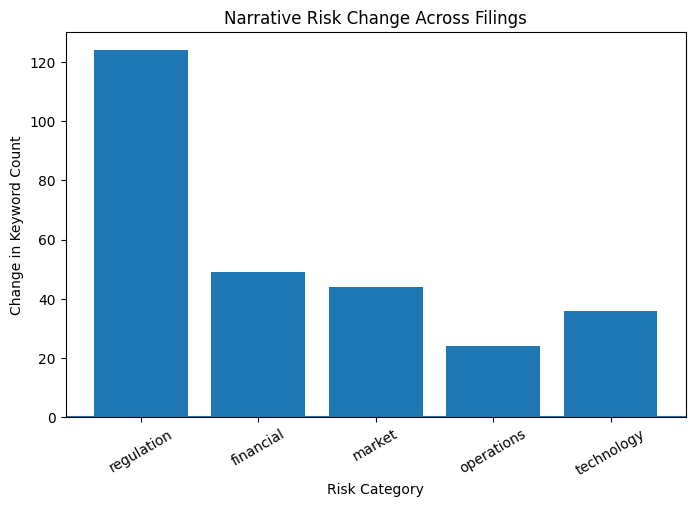

In [65]:
import matplotlib.pyplot as plt

categories = list(risk_change.keys())
changes = list(risk_change.values())

plt.figure(figsize=(8, 5))
plt.bar(categories, changes)
plt.axhline(0)
plt.title("Narrative Risk Change Across Filings")
plt.xlabel("Risk Category")
plt.ylabel("Change in Keyword Count")
plt.xticks(rotation=30)
plt.show()

In [66]:
top_risk_category = max(risk_summary, key=risk_summary.get)
lowest_risk_category = min(risk_summary, key=risk_summary.get)

analyst_explanation = f"""
Credit Risk Narrative Summary

The extracted Risk Factors section shows the strongest signal in {top_risk_category}, with {risk_summary[top_risk_category]} keyword references.

Current risk profile:
- Regulation: {risk_summary['regulation']}
- Financial: {risk_summary['financial']}
- Market: {risk_summary['market']}
- Operations: {risk_summary['operations']}
- Technology: {risk_summary['technology']}

Interpretation:
The filing appears to emphasize {top_risk_category} risk most heavily. This suggests that the analyst should review whether the company is facing increased exposure in this area, especially if the language has become more detailed, cautious, or repetitive across filings.

Recommended human review:
1. Read the full Risk Factors paragraph related to {top_risk_category}.
2. Compare this section against the prior-year filing.
3. Check whether financial metrics or external market signals support the narrative risk.
"""

print(analyst_explanation)


Credit Risk Narrative Summary

The extracted Risk Factors section shows the strongest signal in regulation, with 124 keyword references.

Current risk profile:
- Regulation: 124
- Financial: 49
- Market: 44
- Operations: 24
- Technology: 36

Interpretation:
The filing appears to emphasize regulation risk most heavily. This suggests that the analyst should review whether the company is facing increased exposure in this area, especially if the language has become more detailed, cautious, or repetitive across filings.

Recommended human review:
1. Read the full Risk Factors paragraph related to regulation.
2. Compare this section against the prior-year filing.
3. Check whether financial metrics or external market signals support the narrative risk.



In [67]:
files = sorted([f for f in os.listdir("data/10K") if "V_" in f])

print(files[:5])
print(files[-5:])

['V_10-K_2014-11-21_0001403161-14-000017.html', 'V_10-K_2015-11-20_0001403161-15-000013.html', 'V_10-K_2016-11-15_0001403161-16-000058.html', 'V_10-K_2017-11-17_0001403161-17-000044.html', 'V_10-K_2018-11-16_0001403161-18-000055.html']
['V_10-K_2021-11-18_0001403161-21-000060.html', 'V_10-K_2022-11-16_0001403161-22-000081.html', 'V_10-K_2023-11-15_0001403161-23-000099.html', 'V_10-K_2024-11-13_0001403161-24-000058.html', 'V_10-K_2025-11-06_0001403161-25-000089.html']


In [68]:
older_file = files[0]
newer_file = files[-1]

print("Older file:", older_file)
print("Newer file:", newer_file)

Older file: V_10-K_2014-11-21_0001403161-14-000017.html
Newer file: V_10-K_2025-11-06_0001403161-25-000089.html


In [69]:
def get_positions(lower_text):
    positions = []
    start = 0
    
    while True:
        position = lower_text.find("risk factors", start)
        if position == -1:
            break
        positions.append(position)
        start = position + 1
    
    return positions

In [70]:
def build_risk_summary(file_path):
    clean_text = extract_text(file_path)
    lower_text = clean_text.lower()
    positions = get_positions(lower_text)
    risk_factors_text = extract_section(clean_text, positions, idx=1)
    risk_summary = analyze_risk_text(risk_factors_text)
    return risk_summary, risk_factors_text

risk_summary_older, risk_factors_text_older = build_risk_summary(f"data/10K/{older_file}")
risk_summary_newer, risk_factors_text_newer = build_risk_summary(f"data/10K/{newer_file}")

print("Older:", risk_summary_older)
print("Newer:", risk_summary_newer)

Older: {'regulation': 8, 'financial': 1, 'market': 3, 'operations': 1, 'technology': 5}
Newer: {'regulation': 135, 'financial': 42, 'market': 37, 'operations': 10, 'technology': 18}


In [71]:
risk_change = {}

for key in risk_summary_newer:
    risk_change[key] = risk_summary_newer[key] - risk_summary_older[key]

print(risk_change)

{'regulation': 127, 'financial': 41, 'market': 34, 'operations': 9, 'technology': 13}


In [72]:
sorted_risks = sorted(risk_change.items(), key=lambda x: x[1], reverse=True)

print("Top risk increases:")
for k, v in sorted_risks[:3]:
    print(f"{k}: +{v}")

Top risk increases:
regulation: +127
financial: +41
market: +34


In [73]:
top_risk = sorted_risks[0][0]

final_summary = f"""
Key Insight:

Between {older_file[:10]} and {newer_file[:10]}, the company's risk disclosure shifted most significantly in {top_risk}.

Regulatory-related language increased the most, suggesting growing exposure to compliance, policy, or global regulatory pressure.

This indicates that an analyst should prioritize reviewing regulatory developments and their potential impact on the company's operations and financial performance.
"""

print(final_summary)


Key Insight:

Between V_10-K_201 and V_10-K_202, the company's risk disclosure shifted most significantly in regulation.

Regulatory-related language increased the most, suggesting growing exposure to compliance, policy, or global regulatory pressure.

This indicates that an analyst should prioritize reviewing regulatory developments and their potential impact on the company's operations and financial performance.



In [74]:
# 2024 vs 2025 comparison
files = sorted([f for f in os.listdir("data/10K") if "V_" in f])

recent_files = [f for f in files if "2024" in f or "2025" in f]

print(recent_files)

older_file = recent_files[0]
newer_file = recent_files[-1]

print("Older file:", older_file)
print("Newer file:", newer_file)

['V_10-K_2024-11-13_0001403161-24-000058.html', 'V_10-K_2025-11-06_0001403161-25-000089.html']
Older file: V_10-K_2024-11-13_0001403161-24-000058.html
Newer file: V_10-K_2025-11-06_0001403161-25-000089.html


In [75]:
risk_summary_older, risk_factors_text_older = build_risk_summary(f"data/10K/{older_file}")
risk_summary_newer, risk_factors_text_newer = build_risk_summary(f"data/10K/{newer_file}")

risk_change = {}

for key in risk_summary_newer:
    risk_change[key] = risk_summary_newer[key] - risk_summary_older[key]

print("Older:", risk_summary_older)
print("Newer:", risk_summary_newer)
print("Change:", risk_change)

Older: {'regulation': 124, 'financial': 49, 'market': 44, 'operations': 24, 'technology': 36}
Newer: {'regulation': 135, 'financial': 42, 'market': 37, 'operations': 10, 'technology': 18}
Change: {'regulation': 11, 'financial': -7, 'market': -7, 'operations': -14, 'technology': -18}


In [76]:
top_increase = max(risk_change, key=risk_change.get)
top_decrease = min(risk_change, key=risk_change.get)

print(f"Biggest increase: {top_increase} ({risk_change[top_increase]})")
print(f"Biggest decrease: {top_decrease} ({risk_change[top_decrease]})")

Biggest increase: regulation (11)
Biggest decrease: technology (-18)


In [77]:
analysis_text = f"""
Narrative Risk Shift Summary

Key finding:
- Regulation risk increased by {risk_change['regulation']}.
- Technology risk decreased by {abs(risk_change['technology'])}.
- Operations risk decreased by {abs(risk_change['operations'])}.

Interpretation:
The company appears to be shifting its narrative focus toward regulatory exposure, while de-emphasizing operational and technology-related risks.

This may suggest:
- Increased regulatory scrutiny
- Expansion into regulated markets
- Greater compliance burden

Recommended review:
1. Check "Government Regulation" section in the filing
2. Compare with prior year disclosures
3. Cross-check with external regulatory developments
"""

print(analysis_text)


Narrative Risk Shift Summary

Key finding:
- Regulation risk increased by 11.
- Technology risk decreased by 18.
- Operations risk decreased by 14.

Interpretation:
The company appears to be shifting its narrative focus toward regulatory exposure, while de-emphasizing operational and technology-related risks.

This may suggest:
- Increased regulatory scrutiny
- Expansion into regulated markets
- Greater compliance burden

Recommended review:
1. Check "Government Regulation" section in the filing
2. Compare with prior year disclosures
3. Cross-check with external regulatory developments



In [78]:
def run_risk_agent(older_file, newer_file):
    older_summary, _ = build_risk_summary(older_file)
    newer_summary, _ = build_risk_summary(newer_file)
    
    risk_change = {}
    for key in newer_summary:
        risk_change[key] = newer_summary[key] - older_summary[key]
    
    top_increase = max(risk_change, key=risk_change.get)
    top_decrease = min(risk_change, key=risk_change.get)
    
    return {
        "older": older_summary,
        "newer": newer_summary,
        "change": risk_change,
        "top_increase": top_increase,
        "top_decrease": top_decrease
    }

In [79]:
agent_output = run_risk_agent(
    f"data/10K/{older_file}",
    f"data/10K/{newer_file}"
)

agent_output

{'older': {'regulation': 124,
  'financial': 49,
  'market': 44,
  'operations': 24,
  'technology': 36},
 'newer': {'regulation': 135,
  'financial': 42,
  'market': 37,
  'operations': 10,
  'technology': 18},
 'change': {'regulation': 11,
  'financial': -7,
  'market': -7,
  'operations': -14,
  'technology': -18},
 'top_increase': 'regulation',
 'top_decrease': 'technology'}

In [80]:
def generate_agent_insight(agent_output):
    top_up = agent_output["top_increase"]
    top_down = agent_output["top_decrease"]
    change = agent_output["change"]

    insight = f"""
Risk Narrative Insight

The most significant increase is in {top_up} risk (+{change[top_up]}), 
suggesting growing exposure or emphasis in this area.

The largest decrease is in {top_down} risk ({change[top_down]}), 
which may indicate reduced focus or improved conditions.

Interpretation:
- Rising {top_up} risk may reflect external pressure, regulatory changes, or strategic shifts.
- Declining {top_down} risk could suggest stabilization or deprioritization.

Recommended next steps:
1. Review the full {top_up} risk section in the latest filing.
2. Compare wording changes with prior-year disclosures.
3. Cross-check with financial metrics or external news.
"""

    return insight

In [81]:
insight = generate_agent_insight(agent_output)
print(insight)


Risk Narrative Insight

The most significant increase is in regulation risk (+11), 
suggesting growing exposure or emphasis in this area.

The largest decrease is in technology risk (-18), 
which may indicate reduced focus or improved conditions.

Interpretation:
- Rising regulation risk may reflect external pressure, regulatory changes, or strategic shifts.
- Declining technology risk could suggest stabilization or deprioritization.

Recommended next steps:
1. Review the full regulation risk section in the latest filing.
2. Compare wording changes with prior-year disclosures.
3. Cross-check with financial metrics or external news.



In [82]:
def risk_signal(agent_output, threshold=20):
    signals = []

    for k, v in agent_output["change"].items():
        if v > threshold:
            signals.append(f"⚠️ Significant increase in {k}")
        elif v < -threshold:
            signals.append(f"⬇️ Significant decrease in {k}")

    return signals

In [83]:
signals = risk_signal(agent_output)
print(signals)

[]


In [84]:
final_report = {
    "summary": agent_output,
    "insight": generate_agent_insight(agent_output),
    "signals": risk_signal(agent_output)
}

final_report

{'summary': {'older': {'regulation': 124,
   'financial': 49,
   'market': 44,
   'operations': 24,
   'technology': 36},
  'newer': {'regulation': 135,
   'financial': 42,
   'market': 37,
   'operations': 10,
   'technology': 18},
  'change': {'regulation': 11,
   'financial': -7,
   'market': -7,
   'operations': -14,
   'technology': -18},
  'top_increase': 'regulation',
  'top_decrease': 'technology'},
 'insight': '\nRisk Narrative Insight\n\nThe most significant increase is in regulation risk (+11), \nsuggesting growing exposure or emphasis in this area.\n\nThe largest decrease is in technology risk (-18), \nwhich may indicate reduced focus or improved conditions.\n\nInterpretation:\n- Rising regulation risk may reflect external pressure, regulatory changes, or strategic shifts.\n- Declining technology risk could suggest stabilization or deprioritization.\n\nRecommended next steps:\n1. Review the full regulation risk section in the latest filing.\n2. Compare wording changes with 

In [85]:
def print_final_report(final_report):
    summary = final_report["summary"]
    insight = final_report["insight"]
    signals = final_report["signals"]

    print("LUMEN CREDIT RISK AGENT REPORT")
    print("=" * 40)

    print("\nOlder Filing Risk Summary:")
    print(summary["older"])

    print("\nNewer Filing Risk Summary:")
    print(summary["newer"])

    print("\nRisk Change:")
    print(summary["change"])

    print("\nTop Increase:", summary["top_increase"])
    print("Top Decrease:", summary["top_decrease"])

    print("\nAgent Insight:")
    print(insight)

    print("\nRisk Signals:")
    if signals:
        for signal in signals:
            print("-", signal)
    else:
        print("No high-threshold risk signal detected.")

print_final_report(final_report)

LUMEN CREDIT RISK AGENT REPORT

Older Filing Risk Summary:
{'regulation': 124, 'financial': 49, 'market': 44, 'operations': 24, 'technology': 36}

Newer Filing Risk Summary:
{'regulation': 135, 'financial': 42, 'market': 37, 'operations': 10, 'technology': 18}

Risk Change:
{'regulation': 11, 'financial': -7, 'market': -7, 'operations': -14, 'technology': -18}

Top Increase: regulation
Top Decrease: technology

Agent Insight:

Risk Narrative Insight

The most significant increase is in regulation risk (+11), 
suggesting growing exposure or emphasis in this area.

The largest decrease is in technology risk (-18), 
which may indicate reduced focus or improved conditions.

Interpretation:
- Rising regulation risk may reflect external pressure, regulatory changes, or strategic shifts.
- Declining technology risk could suggest stabilization or deprioritization.

Recommended next steps:
1. Review the full regulation risk section in the latest filing.
2. Compare wording changes with prior-yea

In [86]:
def get_company_files(company):
    files = os.listdir("data/10K")
    company_files = [f for f in files if f.startswith(company + "_10-K")]
    company_files.sort()
    return company_files

def get_latest_pair(company):
    files = get_company_files(company)
    if len(files) < 2:
        return None, None
    return files[-2], files[-1]

In [87]:
older, newer = get_latest_pair("AAPL")

print(older)
print(newer)

AAPL_10-K_2024-11-01_0000320193-24-000123.html
AAPL_10-K_2025-10-31_0000320193-25-000079.html


In [89]:
# Choose company+year
def get_file_by_company_year(company, year):
    files = os.listdir("data/10K")
    
    matches = [
        f for f in files
        if f.startswith(company + "_10-K") and str(year) in f
    ]
    
    if len(matches) == 0:
        return None
    
    matches.sort()
    return matches[-1]

In [90]:
# Test
nvda_2023 = get_file_by_company_year("NVDA", 2023)
tsla_2024 = get_file_by_company_year("TSLA", 2024)

print(nvda_2023)
print(tsla_2024)

NVDA_10-K_2023-02-24_0001045810-23-000017.html
TSLA_10-K_2024-01-29_0001628280-24-002390.html


In [91]:
# Single company year report
def run_single_report(company, year):
    file_name = get_file_by_company_year(company, year)
    
    if file_name is None:
        return f"No filing found for {company} {year}"
    
    risk_summary, risk_factors_text = build_risk_summary(f"data/10K/{file_name}")
    
    top_risk = max(risk_summary, key=risk_summary.get)
    
    single_report = {
        "company": company,
        "year": year,
        "file": file_name,
        "risk_summary": risk_summary,
        "top_risk": top_risk,
        "risk_factors_text": risk_factors_text
    }
    
    return single_report

In [92]:
# Test
single_report = run_single_report("NVDA", 2023)
single_report

{'company': 'NVDA',
 'year': 2023,
 'file': 'NVDA_10-K_2023-02-24_0001045810-23-000017.html',
 'risk_summary': {'regulation': 3,
  'financial': 6,
  'market': 43,
  'operations': 5,
  'technology': 21},
 'top_risk': 'market',
 'risk_factors_text': "Risk Factors.” Given these risks, uncertainties and other factors, you should not place undue reliance on these forward-looking statements. Also, these forward-looking statements represent our estimates and assumptions only as of the date of this filing. You should read this Annual Report on Form 10-K completely and with the understanding that our actual future results may be materially different from what we expect. We hereby qualify our forward-looking statements by these cautionary statements. Except as required by law, we assume no obligation to update these forward-looking statements publicly, or to update the reasons actual results could differ materially from those anticipated in these forward-looking statements, even if new informati

In [94]:
# Comparison report: company A/year A vs company B/year B
def run_comparison_report(company_1, year_1, company_2, year_2):
    report_1 = run_single_report(company_1, year_1)
    report_2 = run_single_report(company_2, year_2)
    
    if isinstance(report_1, str):
        return report_1
    
    if isinstance(report_2, str):
        return report_2
    
    risk_change = {}
    
    for key in report_2["risk_summary"]:
        risk_change[key] = report_2["risk_summary"][key] - report_1["risk_summary"][key]
    
    top_increase = max(risk_change, key=risk_change.get)
    top_decrease = min(risk_change, key=risk_change.get)
    
    comparison_report = {
        "base": report_1,
        "comparison": report_2,
        "risk_change": risk_change,
        "top_increase": top_increase,
        "top_decrease": top_decrease
    }
    
    return comparison_report

In [95]:
# Test
comparison_report = run_comparison_report("NVDA", 2023, "TSLA", 2024)
comparison_report

{'base': {'company': 'NVDA',
  'year': 2023,
  'file': 'NVDA_10-K_2023-02-24_0001045810-23-000017.html',
  'risk_summary': {'regulation': 3,
   'financial': 6,
   'market': 43,
   'operations': 5,
   'technology': 21},
  'top_risk': 'market',
  'risk_factors_text': "Risk Factors.” Given these risks, uncertainties and other factors, you should not place undue reliance on these forward-looking statements. Also, these forward-looking statements represent our estimates and assumptions only as of the date of this filing. You should read this Annual Report on Form 10-K completely and with the understanding that our actual future results may be materially different from what we expect. We hereby qualify our forward-looking statements by these cautionary statements. Except as required by law, we assume no obligation to update these forward-looking statements publicly, or to update the reasons actual results could differ materially from those anticipated in these forward-looking statements, eve

In [99]:
# Print comparison report
def print_comparison_report(comparison_report):
    base = comparison_report["base"]
    comparison = comparison_report["comparison"]
    
    print("LUMEN COMPARISON REPORT")
    print("=" * 40)
    
    print(f"\nBase Filing: {base['company']} {base['year']}")
    print(base["risk_summary"])
    
    print(f"\nComparison Filing: {comparison['company']} {comparison['year']}")
    print(comparison["risk_summary"])
    
    print("\nRisk Difference:")
    print(comparison_report["risk_change"])
    
    print("\nTop Increase:", comparison_report["top_increase"])
    print("Top Decrease:", comparison_report["top_decrease"])
    
    print("\nAgent Insight:")
    print(
        f"The comparison shows the largest relative increase in "
        f"{comparison_report['top_increase']} risk and the largest relative decrease in "
        f"{comparison_report['top_decrease']} risk. A credit analyst should review these sections "
        f"to determine whether the difference reflects company-specific exposure, industry conditions, "
        f"or filing-year changes."
    )

In [123]:
print_comparison_report(comparison_report)

LUMEN COMPARISON REPORT

Base Filing: NVDA 2023
{'regulation': 3, 'financial': 6, 'market': 43, 'operations': 5, 'technology': 21}

Comparison Filing: TSLA 2024
{'regulation': 34, 'financial': 11, 'market': 41, 'operations': 11, 'technology': 8}

Risk Difference:
{'regulation': 31, 'financial': 5, 'market': -2, 'operations': 6, 'technology': -13}

Top Increase: regulation
Top Decrease: technology

Agent Insight:
The comparison shows the largest relative increase in regulation risk and the largest relative decrease in technology risk. A credit analyst should review these sections to determine whether the difference reflects company-specific exposure, industry conditions, or filing-year changes.


In [124]:
# Add confidence
def compute_confidence(change_dict):
    max_change = max(abs(v) for v in change_dict.values())
    
    if max_change > 50:
        return "High"
    elif max_change > 15:
        return "Medium"
    else:
        return "Low"

In [125]:
confidence = compute_confidence(comparison_report["risk_change"])
print("\nConfidence:", confidence)


Confidence: Medium


In [126]:
def get_all_companies():
    files = os.listdir("data/10K")
    companies = sorted(list(set([f.split("_10-K")[0] for f in files if "_10-K" in f])))
    return companies

def get_year_from_file(file_name):
    parts = file_name.split("_")
    for part in parts:
        if part.startswith("20") and len(part) >= 4:
            return int(part[:4])
    return None

def get_company_year_files(company):
    files = get_company_files(company)
    
    company_year_files = []
    for file in files:
        year = get_year_from_file(file)
        if year is not None:
            company_year_files.append((year, file))
    
    company_year_files.sort()
    return company_year_files

In [127]:
all_companies = get_all_companies()

print(all_companies)
print("Total companies:", len(all_companies))

['AAPL', 'AMZN', 'AVGO', 'BRK-B', 'GOOGL', 'JNJ', 'JPM', 'LLY', 'META', 'MSFT', 'MU', 'NVDA', 'TSLA', 'V', 'WMT', 'XOM']
Total companies: 16


In [128]:
portfolio_results = []

for company in all_companies:
    year_files = get_company_year_files(company)
    
    for i in range(len(year_files) - 1):
        older_year, older_file = year_files[i]
        newer_year, newer_file = year_files[i + 1]
        
        try:
            report = run_comparison_report(company, older_year, company, newer_year)
            
            if isinstance(report, str):
                continue
            
            portfolio_results.append({
                "company": company,
                "older_year": older_year,
                "newer_year": newer_year,
                "older_file": older_file,
                "newer_file": newer_file,
                "risk_change": report["risk_change"],
                "top_increase": report["top_increase"],
                "top_decrease": report["top_decrease"]
            })
        
        except Exception as e:
            print("Skipped:", company, older_year, newer_year, e)

print("Total comparisons:", len(portfolio_results))

Total comparisons: 84


In [129]:
import pandas as pd

In [130]:
portfolio_df = pd.DataFrame(rows)
portfolio_df.head()

,company,older_year,newer_year,older_file,newer_file,top_increase,top_decrease,regulation,financial,market,operations,technology
0,AAPL,2015,2016,AAPL_10-K_2015-10-28_0001193125-15-356351.html,AAPL_10-K_2016-10-26_0001628280-16-020309.html,regulation,regulation,0,0,0,0,0
1,AAPL,2016,2017,AAPL_10-K_2016-10-26_0001628280-16-020309.html,AAPL_10-K_2017-11-03_0000320193-17-000070.html,technology,regulation,0,0,0,0,1
2,AAPL,2017,2018,AAPL_10-K_2017-11-03_0000320193-17-000070.html,AAPL_10-K_2018-11-05_0000320193-18-000145.html,regulation,technology,0,0,0,0,-1
3,AAPL,2018,2019,AAPL_10-K_2018-11-05_0000320193-18-000145.html,AAPL_10-K_2019-10-31_0000320193-19-000119.html,market,operations,-1,-2,0,-3,-1
4,AAPL,2019,2020,AAPL_10-K_2019-10-31_0000320193-19-000119.html,AAPL_10-K_2020-10-30_0000320193-20-000096.html,regulation,market,0,0,-6,0,-1


In [131]:
rows = []

for item in portfolio_results:
    row = {
        "company": item["company"],
        "older_year": item["older_year"],
        "newer_year": item["newer_year"],
        "older_file": item["older_file"],
        "newer_file": item["newer_file"],
        "top_increase": item["top_increase"],
        "top_decrease": item["top_decrease"]
    }

    row.update(item["risk_change"])
    rows.append(row)

portfolio_df = pd.DataFrame(rows)
portfolio_df.to_csv("portfolio_risk_comparison.csv", index=False)

portfolio_df.head()

,company,older_year,newer_year,older_file,newer_file,top_increase,top_decrease,regulation,financial,market,operations,technology
0,AAPL,2015,2016,AAPL_10-K_2015-10-28_0001193125-15-356351.html,AAPL_10-K_2016-10-26_0001628280-16-020309.html,regulation,regulation,0,0,0,0,0
1,AAPL,2016,2017,AAPL_10-K_2016-10-26_0001628280-16-020309.html,AAPL_10-K_2017-11-03_0000320193-17-000070.html,technology,regulation,0,0,0,0,1
2,AAPL,2017,2018,AAPL_10-K_2017-11-03_0000320193-17-000070.html,AAPL_10-K_2018-11-05_0000320193-18-000145.html,regulation,technology,0,0,0,0,-1
3,AAPL,2018,2019,AAPL_10-K_2018-11-05_0000320193-18-000145.html,AAPL_10-K_2019-10-31_0000320193-19-000119.html,market,operations,-1,-2,0,-3,-1
4,AAPL,2019,2020,AAPL_10-K_2019-10-31_0000320193-19-000119.html,AAPL_10-K_2020-10-30_0000320193-20-000096.html,regulation,market,0,0,-6,0,-1


In [132]:
portfolio_df.to_csv("portfolio_risk_comparison.csv", index=False)

In [135]:
def get_company_files_by_type(company, filing_type):
    folder = f"data/{filing_type.replace('-', '')}"
    files = os.listdir(folder)
    company_files = [f for f in files if f.startswith(company + f"_{filing_type}")]
    company_files.sort()
    return company_files


def get_year_from_file(file_name):
    parts = file_name.split("_")
    for part in parts:
        if part.startswith("20"):
            return int(part[:4])
    return None


def get_all_companies_by_type(filing_type):
    folder = f"data/{filing_type.replace('-', '')}"
    files = os.listdir(folder)
    companies = sorted(list(set([f.split(f"_{filing_type}")[0] for f in files if f"_{filing_type}" in f])))
    return companies

In [136]:
def build_portfolio_results_for_type(filing_type):
    portfolio_results = []
    companies = get_all_companies_by_type(filing_type)
    folder = f"data/{filing_type.replace('-', '')}"

    for company in companies:
        files = get_company_files_by_type(company, filing_type)

        year_files = []
        for file in files:
            year = get_year_from_file(file)
            if year is not None:
                year_files.append((year, file))

        year_files.sort()

        for i in range(len(year_files) - 1):
            older_year, older_file = year_files[i]
            newer_year, newer_file = year_files[i + 1]

            try:
                older_summary, older_text = build_risk_summary(f"{folder}/{older_file}")
                newer_summary, newer_text = build_risk_summary(f"{folder}/{newer_file}")

                risk_change = {}
                for key in newer_summary:
                    risk_change[key] = newer_summary[key] - older_summary[key]

                top_increase = max(risk_change, key=risk_change.get)
                top_decrease = min(risk_change, key=risk_change.get)

                portfolio_results.append({
                    "company": company,
                    "filing_type": filing_type,
                    "older_year": older_year,
                    "newer_year": newer_year,
                    "older_file": older_file,
                    "newer_file": newer_file,
                    "top_increase": top_increase,
                    "top_decrease": top_decrease,
                    "regulation": risk_change["regulation"],
                    "financial": risk_change["financial"],
                    "market": risk_change["market"],
                    "operations": risk_change["operations"],
                    "technology": risk_change["technology"]
                })

            except Exception as e:
                print("Skipped:", filing_type, company, older_year, newer_year, e)

    return portfolio_results

In [137]:
portfolio_results_10k = build_portfolio_results_for_type("10-K")
portfolio_results_10q = build_portfolio_results_for_type("10-Q")

all_portfolio_results = portfolio_results_10k + portfolio_results_10q

portfolio_df = pd.DataFrame(all_portfolio_results)

portfolio_df.to_csv("portfolio_risk_comparison.csv", index=False)

print("Total rows:", len(portfolio_df))
portfolio_df.head()

Total rows: 178


,company,filing_type,older_year,newer_year,older_file,newer_file,top_increase,top_decrease,regulation,financial,market,operations,technology
0,AAPL,10-K,2015,2016,AAPL_10-K_2015-10-28_0001193125-15-356351.html,AAPL_10-K_2016-10-26_0001628280-16-020309.html,regulation,regulation,0,0,0,0,0
1,AAPL,10-K,2016,2017,AAPL_10-K_2016-10-26_0001628280-16-020309.html,AAPL_10-K_2017-11-03_0000320193-17-000070.html,technology,regulation,0,0,0,0,1
2,AAPL,10-K,2017,2018,AAPL_10-K_2017-11-03_0000320193-17-000070.html,AAPL_10-K_2018-11-05_0000320193-18-000145.html,regulation,technology,0,0,0,0,-1
3,AAPL,10-K,2018,2019,AAPL_10-K_2018-11-05_0000320193-18-000145.html,AAPL_10-K_2019-10-31_0000320193-19-000119.html,regulation,market,-1,-2,-6,-3,-3
4,AAPL,10-K,2019,2020,AAPL_10-K_2019-10-31_0000320193-19-000119.html,AAPL_10-K_2020-10-30_0000320193-20-000096.html,technology,regulation,0,0,0,0,1


In [138]:
portfolio_df.columns

Index(['company', 'filing_type', 'older_year', 'newer_year', 'older_file',
       'newer_file', 'top_increase', 'top_decrease', 'regulation', 'financial',
       'market', 'operations', 'technology'],
      dtype='object')

In [2]:
# 🔗 Live App (Streamlit):
# https://your-app-name.streamlit.app

# 🔗 GitHub Repository:
# https://github.com/autosoon-commits/Lumen-Financial-Risk-Agent